In [ ]:
import pandas as pd
import networkx as nx


In [ ]:
df = pd.read_csv("/content/rounds_kills.csv")

df.head()


,Tournament,Stage,Match Type,Match Name,Map,Round Number,Eliminator Team,Eliminator,Eliminator Agent,Eliminated Team,Eliminated,Eliminated Agent,Kill Type
0,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,1,Xi Lai Gaming,NoMan,jett,Mega Minors,mada,waylay,2k
1,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,1,Xi Lai Gaming,NoMan,jett,Mega Minors,keiko,vyse,2k
2,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,2,Xi Lai Gaming,NoMan,jett,Mega Minors,brawk,sova,2k
3,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,2,Xi Lai Gaming,NoMan,jett,Mega Minors,skuba,astra,2k
4,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,6,Xi Lai Gaming,NoMan,jett,Mega Minors,Ethan,tejo,2k


In [ ]:
df = df[df['Tournament'] == 'Valorant Masters London 2026'].copy()
display(df.head())

,Tournament,Stage,Match Type,Match Name,Map,Round Number,Eliminator Team,Eliminator,Eliminator Agent,Eliminated Team,Eliminated,Eliminated Agent,Kill Type
0,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,1,Xi Lai Gaming,NoMan,jett,Mega Minors,mada,waylay,2k
1,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,1,Xi Lai Gaming,NoMan,jett,Mega Minors,keiko,vyse,2k
2,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,2,Xi Lai Gaming,NoMan,jett,Mega Minors,brawk,sova,2k
3,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,2,Xi Lai Gaming,NoMan,jett,Mega Minors,skuba,astra,2k
4,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,6,Xi Lai Gaming,NoMan,jett,Mega Minors,Ethan,tejo,2k


In [ ]:
features = [
    "Stage" ,"Eliminator Agent", "Match Name",
     "Eliminated", "Eliminated Agent"
  ]
eliminator_df = df[["Eliminator"] + features].copy()

eliminator_df = eliminator_df.fillna(0)

eliminator_df.head()



,Eliminator,Stage,Eliminator Agent,Match Name,Eliminated,Eliminated Agent
0,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,mada,waylay
1,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,keiko,vyse
2,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,brawk,sova
3,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,skuba,astra
4,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,Ethan,tejo


In [ ]:
display(df)

,Tournament,Stage,Match Type,Match Name,Map,Round Number,Eliminator Team,Eliminator,Eliminator Agent,Eliminated Team,Eliminated,Eliminated Agent,Kill Type
0,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,1,Xi Lai Gaming,NoMan,jett,Mega Minors,mada,waylay,2k
1,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,1,Xi Lai Gaming,NoMan,jett,Mega Minors,keiko,vyse,2k
2,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,2,Xi Lai Gaming,NoMan,jett,Mega Minors,brawk,sova,2k
3,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,2,Xi Lai Gaming,NoMan,jett,Mega Minors,skuba,astra,2k
4,Valorant Masters London 2026,Swiss Stage,Round 1,Xi Lai Gaming vs NRG,Pearl,6,Xi Lai Gaming,NoMan,jett,Mega Minors,Ethan,tejo,2k
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5559,Valorant Masters London 2026,Playoffs,Grand Final,Paper Rex vs LEVIATÁN,Lotus,11,LEVIATÁN,Neon,jett,Paper Rex,f0rsakeN,omen,2k
5560,Valorant Masters London 2026,Playoffs,Grand Final,Paper Rex vs LEVIATÁN,Lotus,12,LEVIATÁN,Neon,jett,Paper Rex,Jinggg,raze,2k
5561,Valorant Masters London 2026,Playoffs,Grand Final,Paper Rex vs LEVIATÁN,Lotus,12,LEVIATÁN,Neon,jett,Paper Rex,invy,skye,2k
5562,Valorant Masters London 2026,Playoffs,Grand Final,Paper Rex vs LEVIATÁN,Lotus,13,LEVIATÁN,Neon,jett,Paper Rex,something,jett,2k


In [ ]:
display(eliminator_df)

,Eliminator,Stage,Eliminator Agent,Match Name,Eliminated,Eliminated Agent
0,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,mada,waylay
1,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,keiko,vyse
2,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,brawk,sova
3,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,skuba,astra
4,NoMan,Swiss Stage,jett,Xi Lai Gaming vs NRG,Ethan,tejo
...,...,...,...,...,...,...
5559,Neon,Playoffs,jett,Paper Rex vs LEVIATÁN,f0rsakeN,omen
5560,Neon,Playoffs,jett,Paper Rex vs LEVIATÁN,Jinggg,raze
5561,Neon,Playoffs,jett,Paper Rex vs LEVIATÁN,invy,skye
5562,Neon,Playoffs,jett,Paper Rex vs LEVIATÁN,something,jett


In [ ]:
g = nx.DiGraph()


In [ ]:
for player in eliminator_df["Eliminator"]:
    g.add_node(player)

In [ ]:
all_players = pd.concat([eliminator_df['Eliminator'], eliminator_df['Eliminated']]).unique()
g.add_nodes_from(all_players)

print(f"Number of nodes (unique players): {g.number_of_nodes()}")


Number of nodes (unique players): 60


In [ ]:
for index, row in eliminator_df.iterrows():
    eliminator = row['Eliminator']
    eliminated = row['Eliminated']

    if g.has_edge(eliminator, eliminated):
        g[eliminator][eliminated]['weight'] += 1
    else:
        g.add_edge(eliminator, eliminated, weight=1)

print(f"Number of edges (unique kill interactions): {g.number_of_edges()}")





Number of edges (unique kill interactions): 1104


In [ ]:
outdegree = nx.out_degree_centrality(g)
eigenvector = nx.eigenvector_centrality(g)


In [ ]:
results = pd.DataFrame({
    "Player": list(g.nodes()),
    "Eigenvector Centrality": [eigenvector[player] for player in g.nodes()],
    "Out-Degree Centrality": [c_degree[player] for player in g.nodes()]
})

display(results.head())

,Player,Eigenvector Centrality,Out-Degree Centrality
0,NoMan,0.050402,0.133621
1,mada,0.116504,0.323276
2,keiko,0.118169,0.336207
3,brawk,0.120074,0.323276
4,skuba,0.115624,0.323276


In [ ]:
sorted_by_eigenvector = results.sort_values(by='Eigenvector Centrality', ascending=False)
display(sorted_by_eigenvector.head(10))

,Player,Eigenvector Centrality,Out-Degree Centrality
40,Jinggg,0.125479,0.353448
43,d4v41,0.125479,0.349138
44,something,0.125479,0.353448
41,invy,0.125479,0.353448
42,f0rsakeN,0.124159,0.353448
56,valyn,0.122149,0.349138
58,leaf,0.122025,0.353448
59,trent,0.121441,0.357759
3,brawk,0.120074,0.323276
55,BABYBAY,0.119583,0.353448


In [ ]:
sorted_by_out_degree = results.sort_values(by='Out-Degree Centrality', ascending=False)
display(sorted_by_out_degree.head(10))

,Player,Eigenvector Centrality,Out-Degree Centrality
59,trent,0.121441,0.357759
42,f0rsakeN,0.124159,0.353448
44,something,0.125479,0.353448
55,BABYBAY,0.119583,0.353448
58,leaf,0.122025,0.353448
41,invy,0.125479,0.353448
40,Jinggg,0.125479,0.353448
36,Sato,0.116857,0.349138
37,spike,0.114546,0.349138
43,d4v41,0.125479,0.349138


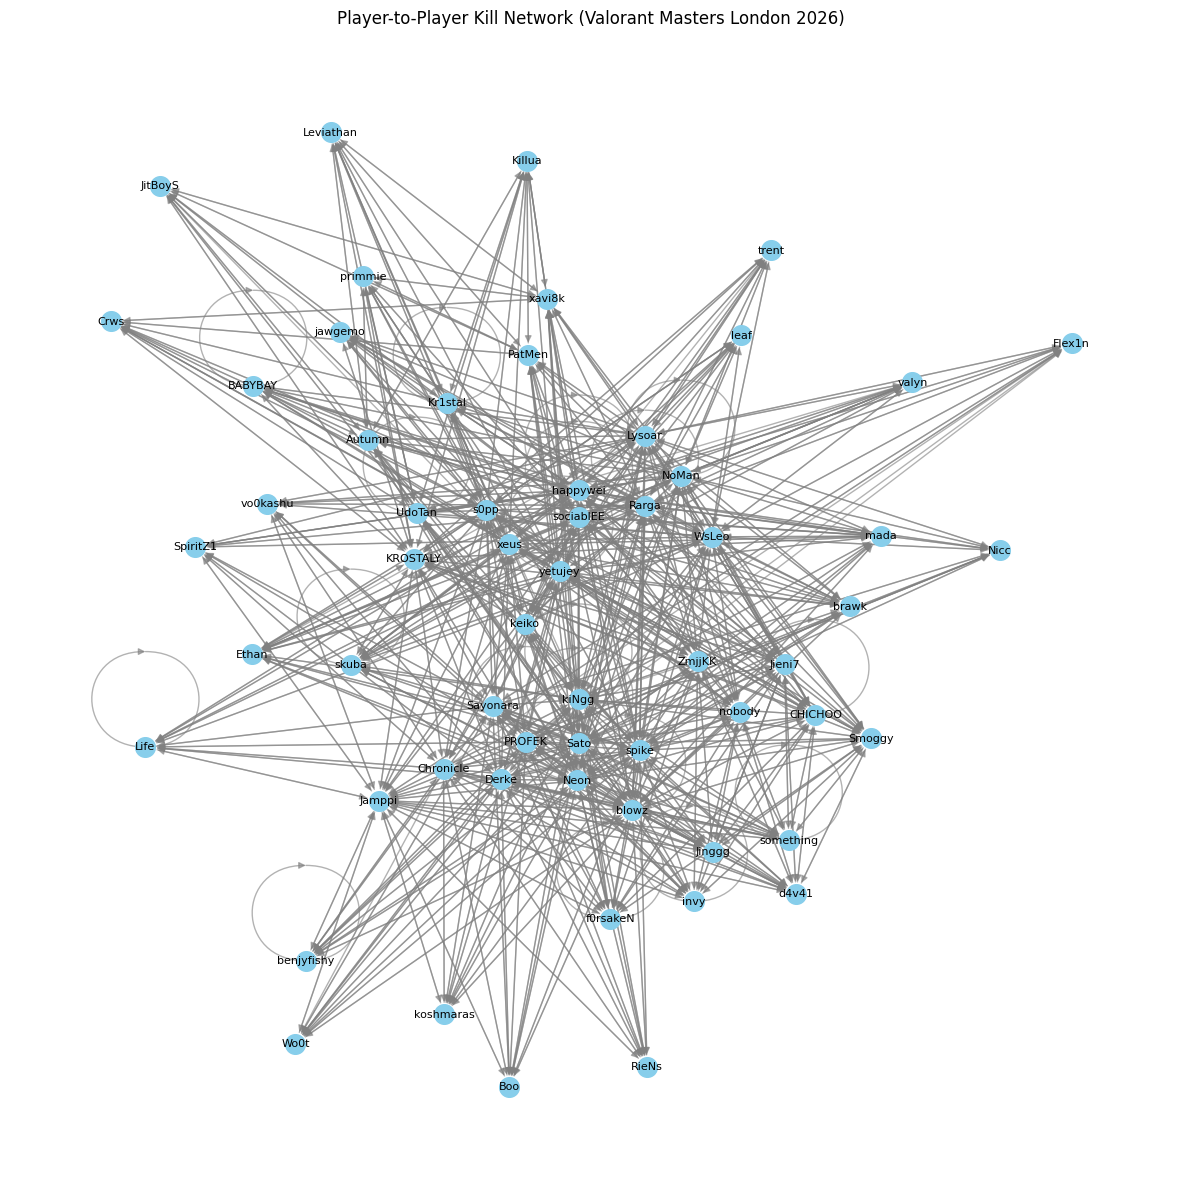

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

pos = nx.spring_layout(g, k=0.15, iterations=50, seed=42)

nx.draw_networkx_nodes(g, pos, node_size=200, node_color='skyblue')

nx.draw_networkx_edges(g, pos, arrowsize=10, edge_color='gray', alpha=0.6)

nx.draw_networkx_labels(g, pos, font_size=8, font_color='black')

plt.title("Player-to-Player Kill Network (Valorant Masters London 2026)")
plt.axis('off')
plt.show()